In [ ]:
import torch
from torch import nn
from scipy.stats import qmc

#| Architecture | 8 hidden layers × 20 neurons, tanh, matching rassi

class NeuralNetwork(nn.Module):
    def __init__(self,lb,ub):
        super().__init__()
        self.lb = lb
        self.ub = ub
        self.net = nn.Sequential(
            nn.Linear(2,20), nn.Tanh(),
            nn.Linear(20,20), nn.Tanh(),
            nn.Linear(20,20), nn.Tanh(),
            nn.Linear(20,20), nn.Tanh(),
            nn.Linear(20,20), nn.Tanh(),
            nn.Linear(20,20), nn.Tanh(),
            nn.Linear(20,20), nn.Tanh(),
            nn.Linear(20,20), nn.Tanh(),
            nn.Linear(20,1),
        )
        
    def forward(self, X):
        X = 2.0 * (X - self.lb) / (self.ub - self.lb) - 1.0
        return self.net(X)


N_ic, N_b, N_f = 256, 200, 10000
N_u = 100
#initial condition for x [-1,1], ic for t [0,1], true value for ic
x_ic = 2 * torch.rand(N_ic, 1) - 1
t_ic = torch.zeros(N_ic, 1)
u_ic = -torch.sin(torch.pi * x_ic)

#boundary condition half -1 half 1
t_bc = torch.rand(N_b, 1)
x_bc = torch.cat([-torch.ones(N_b//2,1), torch.ones(N_b//2,1)])
u_bc = torch.zeros(N_b,1)

#shape: [456,2] the initial condition on top, bc below
X_all = torch.cat([torch.cat([x_ic, t_ic], 1), torch.cat([x_bc, t_bc], 1)])
u_all = torch.cat([u_ic, u_bc]) # [456,1] for target value

#random sampling 100 points from 456 candidate points
idx = torch.randperm(X_all.shape[0])[:N_u]
X_u, u_u = X_all[idx], u_all[idx]   # [100,2], [100,1]

#Latin Hypercube sampling method mentioned in the paper
sampler = qmc.LatinHypercube(d=2)
pts = sampler.random(n=N_f)
pts = qmc.scale(pts, [-1.0, 0.0], [1.0, 1.0])
pts_t = torch.tensor(pts, dtype=torch.float32)   # [10000,2], no grad flag yet

#residual points: LHS interior + all 456 boundary/initial points
X_f = torch.cat([pts_t, X_all])                  # [10456,2]

#split into leaves so autograd can differentiate w.r.t. each coordinate
x_f = X_f[:, 0:1].clone().requires_grad_(True)   # [10456,1]
t_f = X_f[:, 1:2].clone().requires_grad_(True)   # [10456,1]

loss_fn = nn.MSELoss()



In [43]:

def train_model(model):

    def compute_loss():
        u_pred_bic = model(X_u) #bic:boundary and initial conditon
        u = model(torch.cat([x_f, t_f], dim=1))
        u_t = torch.autograd.grad(u, t_f, torch.ones_like(u), create_graph=True)[0]
        u_x = torch.autograd.grad(u, x_f, torch.ones_like(u), create_graph=True)[0]
        u_xx = torch.autograd.grad(u_x,x_f,torch.ones_like(u_x),create_graph = True)[0]
        residual = u_t + u* u_x - 0.01/(torch.pi) * u_xx

        loss_bic  = loss_fn(u_pred_bic, u_u)

        loss_pde = loss_fn(residual, torch.zeros_like(residual))
        return loss_bic + loss_pde
    
    lbfgs = torch.optim.LBFGS(model.parameters(), lr=1.0,
                  max_iter=50000, max_eval=50000,
                  history_size=50,
                  tolerance_grad=1e-9, tolerance_change=1e-11,
                  line_search_fn="strong_wolfe")
    
    
    def closure():
        lbfgs.zero_grad()
        loss = compute_loss()
        loss.backward()
        return loss

    lbfgs.step(closure)
    return compute_loss().item()


lb = torch.tensor([[-1.0, 0.0]])
ub = torch.tensor([[ 1.0, 1.0]])
model = NeuralNetwork(lb, ub)

final_loss = train_model(model)
print(final_loss)




4.152508154220413e-06


In [44]:
import scipy.io
import numpy as np
data = scipy.io.loadmat('burgers_shock.mat')
print(data['x'].shape, data['t'].shape, data['usol'].shape)

x = torch.tensor(data['x'], dtype=torch.float32)   # [256, 1]
t = torch.tensor(data['t'], dtype=torch.float32)   # [100, 1]
usol = torch.tensor(data['usol'], dtype=torch.float32)

X, T = torch.meshgrid(x.flatten(), t.flatten(), indexing='ij')

x_eval = X.reshape(-1, 1)
t_eval = T.reshape(-1, 1)


with torch.no_grad():
    u_pred = model(torch.cat([x_eval, t_eval], dim=1))
    u_exact = usol.reshape(-1, 1)
    error = torch.norm(u_pred - u_exact) / torch.norm(u_exact)
print(error.item())




(256, 1) (100, 1) (256, 100)
0.0009118295856751502


In [ ]:
# check whether the reference data is correct
print(usol[0,:].abs().max())
print(usol[-1,:].abs().max())

tensor(3.5730e-16)
tensor(3.1682e-16)


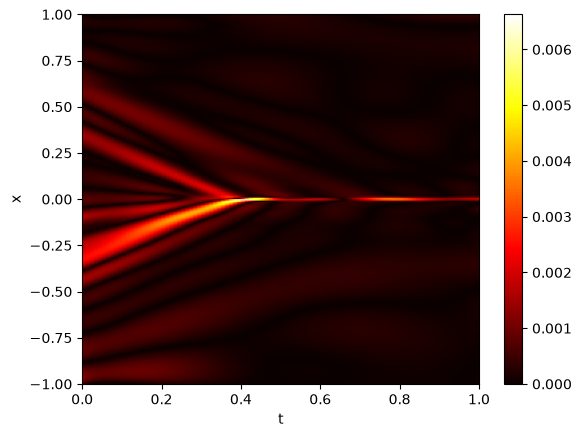

0.006629139184951782


In [46]:
import matplotlib.pyplot as plt
err = (u_pred - u_exact).abs().reshape(256, 100)
plt.imshow(err, aspect='auto', origin='lower',
           extent=[0, 1, -1, 1], cmap='hot')
plt.colorbar(); plt.xlabel('t'); plt.ylabel('x')
plt.show()
print(err.max().item())

In [49]:
import torch
from torch import nn
import numpy as np
import scipy.io
from scipy.stats import qmc

# ---------------------------------------------------------------- model
# 8 hidden layers x 20 neurons, tanh — matching Raissi [2, 20*8, 1]

class NeuralNetwork(nn.Module):
    def __init__(self, lb, ub):
        super().__init__()
        self.lb = lb
        self.ub = ub
        self.net = nn.Sequential(
            nn.Linear(2,20),  nn.Tanh(),
            nn.Linear(20,20), nn.Tanh(),
            nn.Linear(20,20), nn.Tanh(),
            nn.Linear(20,20), nn.Tanh(),
            nn.Linear(20,20), nn.Tanh(),
            nn.Linear(20,20), nn.Tanh(),
            nn.Linear(20,20), nn.Tanh(),
            nn.Linear(20,20), nn.Tanh(),
            nn.Linear(20,1),
        )

    def forward(self, X):
        X = 2.0 * (X - self.lb) / (self.ub - self.lb) - 1.0
        return self.net(X)


def init_xavier(m):
    # Raissi initializes with Xavier; PyTorch's nn.Linear default is
    # Kaiming-uniform, which is tuned for ReLU rather than tanh.
    if isinstance(m, nn.Linear):
        nn.init.xavier_normal_(m.weight)
        nn.init.zeros_(m.bias)


# ---------------------------------------------------------------- setup

N_ic, N_b, N_f = 256, 200, 10000
N_u = 100
nu = 0.01 / torch.pi

lb = torch.tensor([[-1.0, 0.0]])
ub = torch.tensor([[ 1.0, 1.0]])

loss_fn = nn.MSELoss()

# reference solution
data = scipy.io.loadmat('burgers_shock.mat')
x_ref = torch.tensor(data['x'], dtype=torch.float32)      # [256,1]
t_ref = torch.tensor(data['t'], dtype=torch.float32)      # [100,1]
usol  = torch.tensor(data['usol'], dtype=torch.float32)   # [256,100]

X, T = torch.meshgrid(x_ref.flatten(), t_ref.flatten(), indexing='ij')
x_eval  = X.reshape(-1, 1)        # [25600,1]
t_eval  = T.reshape(-1, 1)
u_exact = usol.reshape(-1, 1)     # [25600,1]


# ---------------------------------------------------------------- one run

def run_once(xavier=True):
    # initial condition: t = 0, x in [-1,1]
    x_ic = 2 * torch.rand(N_ic, 1) - 1
    t_ic = torch.zeros(N_ic, 1)
    u_ic = -torch.sin(torch.pi * x_ic)

    # boundaries: x = -1 and x = +1, u = 0
    t_bc = torch.rand(N_b, 1)
    x_bc = torch.cat([-torch.ones(N_b//2,1), torch.ones(N_b//2,1)])
    u_bc = torch.zeros(N_b, 1)

    X_all = torch.cat([torch.cat([x_ic, t_ic], 1),
                       torch.cat([x_bc, t_bc], 1)])      # [456,2]
    u_all = torch.cat([u_ic, u_bc])                       # [456,1]

    # sample N_u supervised points from the 456 candidates
    idx = torch.randperm(X_all.shape[0])[:N_u]
    X_u, u_u = X_all[idx], u_all[idx]

    # collocation: LHS interior + all boundary/initial points
    pts = qmc.scale(qmc.LatinHypercube(d=2).random(n=N_f), [-1.0, 0.0], [1.0, 1.0])
    X_f = torch.cat([torch.tensor(pts, dtype=torch.float32), X_all])   # [10456,2]
    x_f = X_f[:, 0:1].clone().requires_grad_(True)
    t_f = X_f[:, 1:2].clone().requires_grad_(True)

    model = NeuralNetwork(lb, ub)
    if xavier:
        model.apply(init_xavier)

    def compute_loss():
        u_pred_bic = model(X_u)

        u = model(torch.cat([x_f, t_f], dim=1))
        u_t  = torch.autograd.grad(u, t_f, torch.ones_like(u), create_graph=True)[0]
        u_x  = torch.autograd.grad(u, x_f, torch.ones_like(u), create_graph=True)[0]
        u_xx = torch.autograd.grad(u_x, x_f, torch.ones_like(u_x), create_graph=True)[0]
        residual = u_t + u * u_x - nu * u_xx

        return (loss_fn(u_pred_bic, u_u)
                + loss_fn(residual, torch.zeros_like(residual)))

    lbfgs = torch.optim.LBFGS(model.parameters(), lr=1.0,
                              max_iter=50000, max_eval=50000,
                              history_size=50,
                              tolerance_grad=1e-9, tolerance_change=1e-11,
                              line_search_fn="strong_wolfe")

    calls = [0]
    def closure():
        calls[0] += 1
        lbfgs.zero_grad()
        loss = compute_loss()
        loss.backward()
        return loss

    lbfgs.step(closure)

    with torch.no_grad():
        u_pred = model(torch.cat([x_eval, t_eval], dim=1))
        err = (torch.norm(u_pred - u_exact) / torch.norm(u_exact)).item()

    return compute_loss().item(), err, calls[0]


# ---------------------------------------------------------------- 10 seeds

results = []
for seed in range(10):
    torch.manual_seed(seed)
    np.random.seed(seed)
    loss, err, calls = run_once(xavier=True)
    results.append(err)
    print(f"seed {seed}: loss={loss:.2e}  L2={err:.2e}  closure calls={calls}")

r = np.array(results)
print(f"\nmean={r.mean():.2e}  median={np.median(r):.2e}  "
      f"min={r.min():.2e}  max={r.max():.2e}")
print("Raissi reported: 6.7e-4")
print("Default init (10 seeds): mean=4.46e-03  min=1.26e-03  max=9.55e-03")

seed 0: loss=1.93e-05  L2=3.07e-03  closure calls=3861
seed 1: loss=9.48e-06  L2=4.74e-03  closure calls=3212
seed 2: loss=4.19e-06  L2=7.43e-04  closure calls=5480
seed 3: loss=4.74e-06  L2=1.91e-03  closure calls=4082
seed 4: loss=1.76e-06  L2=6.86e-04  closure calls=5215
seed 5: loss=7.96e-06  L2=1.14e-03  closure calls=5165
seed 6: loss=4.10e-06  L2=1.75e-03  closure calls=5002
seed 7: loss=6.80e-06  L2=1.39e-03  closure calls=3548
seed 8: loss=3.80e-06  L2=4.66e-03  closure calls=5075
seed 9: loss=7.71e-06  L2=4.99e-03  closure calls=4274

mean=2.51e-03  median=1.83e-03  min=6.86e-04  max=4.99e-03
Raissi reported: 6.7e-4
Default init (10 seeds): mean=4.46e-03  min=1.26e-03  max=9.55e-03
